# 03 - Image Preprocessing

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

In this notebook, we will prepare FOD-A images for the object-detection model.

We will learn and implement:

- Loading an image
- Reading Pascal VOC bounding boxes
- Displaying an image with its bounding boxes
- Resizing images
- Converting bounding boxes after resizing
- Basic image normalization
- Basic image augmentation
- Checking that augmentation keeps bounding boxes correct

We will keep this notebook simple and focus on understanding the image
preprocessing pipeline before model training.


## 1. Import Libraries

In [8]:
import sys
print(sys.executable)

from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import numpy as np

import cv2
import matplotlib.pyplot as plt


d:\Projects\AI Runway FOD Detection\.venv\Scripts\python.exe


## 2. Project Paths

In [9]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "FODPascalVOCFormat-V.2.1"
    / "VOC2007"
)

IMAGE_DIR = DATA_ROOT / "JPEGImages"
ANNOTATION_DIR = DATA_ROOT / "Annotations"

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "fod_annotations.csv"
)

print("Image directory:", IMAGE_DIR)
print("Annotation directory:", ANNOTATION_DIR)


Image directory: d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\JPEGImages
Annotation directory: d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\Annotations


## 3. Load the Processed Annotation Data

In [10]:
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (34472, 25)


,image_id,filename,image_path,annotation_path,split,width,height,class_name,xmin,ymin,...,pose,track_id,keyframe,weather_label,light_label,image_exists,x_center,y_center,box_width,box_height
0,0,000000.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2219,104.2833,...,Unspecified,0,True,Wet,Dim,True,0.482771,0.421051,0.044062,0.14688
1,1,000001.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2422,104.7611,...,Unspecified,0,False,Wet,Dim,True,0.482841,0.422644,0.044068,0.14688
2,2,000002.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2641,105.2389,...,Unspecified,0,False,Wet,Dim,True,0.482911,0.424236,0.044062,0.14688
3,3,000003.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2844,105.7167,...,Unspecified,0,False,Wet,Dim,True,0.482979,0.425829,0.044063,0.14688
4,4,000004.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.3047,106.1945,...,Unspecified,0,False,Wet,Dim,True,0.483047,0.427417,0.044062,0.14687


In [11]:
print("Image path:")
print(image_path)

print("\nExists:")
print(image_path.exists())

print("\nIs file:")
print(image_path.is_file())

Image path:
d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\JPEGImages\000000.jpg

Exists:
True

Is file:
True


## 4. Select One Image

In [12]:
# Select the first image from the dataset
image_id = df["image_id"].iloc[0]

# Use the original filename from the CSV
image_filename = df["filename"].iloc[0]

image_path = IMAGE_DIR / image_filename
annotation_path = ANNOTATION_DIR / f"{image_id:06d}.xml"

print("Image ID:", image_id)
print("Image filename:", image_filename)
print("Image path:", image_path)
print("Annotation path:", annotation_path)

Image ID: 0
Image filename: 000000.jpg
Image path: d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\JPEGImages\000000.jpg
Annotation path: d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\Annotations\000000.xml


## 5. Load and Display the Image

Image shape: (300, 300, 3)


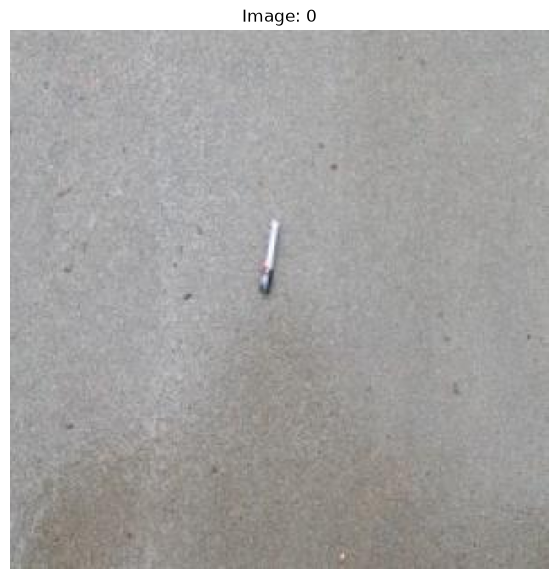

In [13]:
# Read image using OpenCV
image = cv2.imread(str(image_path))

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image shape:", image_rgb.shape)

plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title(f"Image: {image_id}")
plt.axis("off")
plt.show()


## 6. Read Pascal VOC Bounding Boxes

In [14]:
# Read the XML annotation
tree = ET.parse(annotation_path)
root = tree.getroot()

objects = []

for object_element in root.findall("object"):

    class_name = object_element.findtext("name")

    bbox = object_element.find("bndbox")

    xmin = float(bbox.findtext("xmin"))
    ymin = float(bbox.findtext("ymin"))
    xmax = float(bbox.findtext("xmax"))
    ymax = float(bbox.findtext("ymax"))

    objects.append(
        {
            "class_name": class_name,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        }
    )

objects


[{'class_name': 'Battery',
  'xmin': 138.2219,
  'ymin': 104.2833,
  'xmax': 151.4406,
  'ymax': 148.3472}]

## 7. Display Image with Bounding Boxes

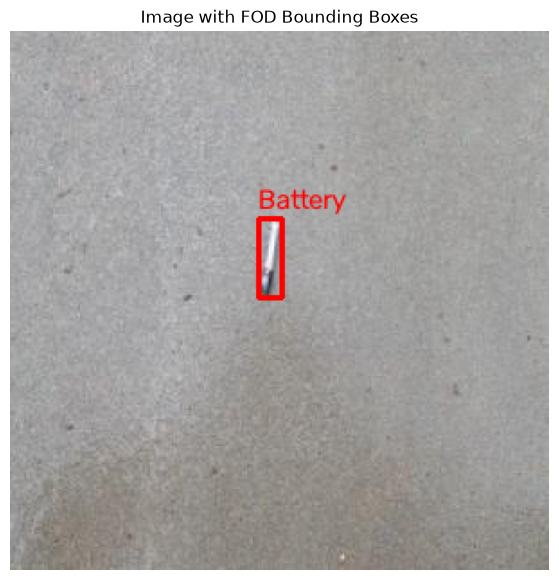

In [15]:
image_with_boxes = image_rgb.copy()

for obj in objects:

    xmin = int(obj["xmin"])
    ymin = int(obj["ymin"])
    xmax = int(obj["xmax"])
    ymax = int(obj["ymax"])

    class_name = obj["class_name"]

    cv2.rectangle(
        image_with_boxes,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image_with_boxes,
        class_name,
        (xmin, max(ymin - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(7, 7))
plt.imshow(image_with_boxes)
plt.title("Image with FOD Bounding Boxes")
plt.axis("off")
plt.show()


## 8. Why Bounding Boxes Must Be Transformed

When we resize an image, the object moves to a different pixel location.

For example:

Original image:
`300 × 300`

If we resize it to:
`640 × 640`

the bounding-box coordinates must also be changed.

The object itself has not changed, but its pixel coordinates have changed.

This is very important for object detection.


## 9. Resize Image and Bounding Boxes

In [16]:
TARGET_WIDTH = 640
TARGET_HEIGHT = 640

original_height, original_width = image_rgb.shape[:2]

resized_image = cv2.resize(
    image_rgb,
    (TARGET_WIDTH, TARGET_HEIGHT)
)

x_scale = TARGET_WIDTH / original_width
y_scale = TARGET_HEIGHT / original_height

resized_objects = []

for obj in objects:

    new_xmin = obj["xmin"] * x_scale
    new_ymin = obj["ymin"] * y_scale
    new_xmax = obj["xmax"] * x_scale
    new_ymax = obj["ymax"] * y_scale

    resized_objects.append(
        {
            "class_name": obj["class_name"],
            "xmin": new_xmin,
            "ymin": new_ymin,
            "xmax": new_xmax,
            "ymax": new_ymax
        }
    )

print("Original image size:", original_width, "x", original_height)
print("New image size:", TARGET_WIDTH, "x", TARGET_HEIGHT)
print("Scale X:", x_scale)
print("Scale Y:", y_scale)


Original image size: 300 x 300
New image size: 640 x 640
Scale X: 2.1333333333333333
Scale Y: 2.1333333333333333


## 10. Display Resized Image with New Bounding Boxes

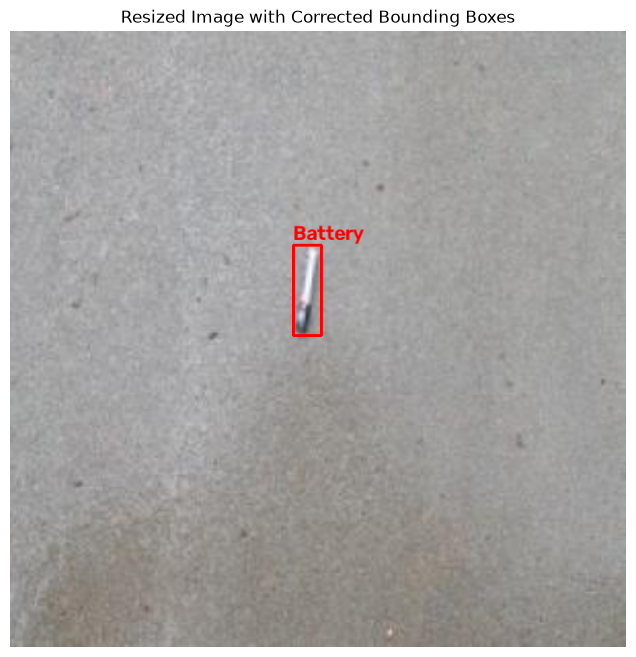

In [17]:
resized_image_with_boxes = resized_image.copy()

for obj in resized_objects:

    xmin = int(obj["xmin"])
    ymin = int(obj["ymin"])
    xmax = int(obj["xmax"])
    ymax = int(obj["ymax"])

    class_name = obj["class_name"]

    cv2.rectangle(
        resized_image_with_boxes,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

    cv2.putText(
        resized_image_with_boxes,
        class_name,
        (xmin, max(ymin - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8, 8))
plt.imshow(resized_image_with_boxes)
plt.title("Resized Image with Corrected Bounding Boxes")
plt.axis("off")
plt.show()


## 11. Normalize Image Pixels

Images are normally stored with pixel values from 0 to 255.

Neural networks usually work better when the input values are scaled.

A simple normalization is:

`pixel / 255`

This converts the values to the range:

`0 to 1`


In [18]:
# Convert image values from 0-255 to 0-1
normalized_image = resized_image.astype(np.float32) / 255.0

print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())
print("Data type:", normalized_image.dtype)


Minimum pixel value: 0.1764706
Maximum pixel value: 1.0
Data type: float32


## 12. Convert Bounding Boxes to Normalized Coordinates

In [19]:
normalized_boxes = []

for obj in resized_objects:

    xmin = obj["xmin"] / TARGET_WIDTH
    ymin = obj["ymin"] / TARGET_HEIGHT
    xmax = obj["xmax"] / TARGET_WIDTH
    ymax = obj["ymax"] / TARGET_HEIGHT

    normalized_boxes.append(
        {
            "class_name": obj["class_name"],
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        }
    )

normalized_boxes


[{'class_name': 'Battery',
  'xmin': 0.46073966666666666,
  'ymin': 0.347611,
  'xmax': 0.504802,
  'ymax': 0.49449066666666663}]

## 13. Horizontal Flip Augmentation

A horizontal flip changes the position of the object.

Therefore, the bounding-box coordinates must also be changed.

For an image width `W`:

- New xmin = `W - old xmax`
- New xmax = `W - old xmin`

The y coordinates stay the same.


In [20]:
flipped_image = cv2.flip(resized_image, 1)

flipped_objects = []

for obj in resized_objects:

    new_xmin = TARGET_WIDTH - obj["xmax"]
    new_xmax = TARGET_WIDTH - obj["xmin"]

    flipped_objects.append(
        {
            "class_name": obj["class_name"],
            "xmin": new_xmin,
            "ymin": obj["ymin"],
            "xmax": new_xmax,
            "ymax": obj["ymax"]
        }
    )

print(flipped_objects)


[{'class_name': 'Battery', 'xmin': 316.92672000000005, 'ymin': 222.47104, 'xmax': 345.12661333333335, 'ymax': 316.47402666666665}]


## 14. Display Horizontally Flipped Image

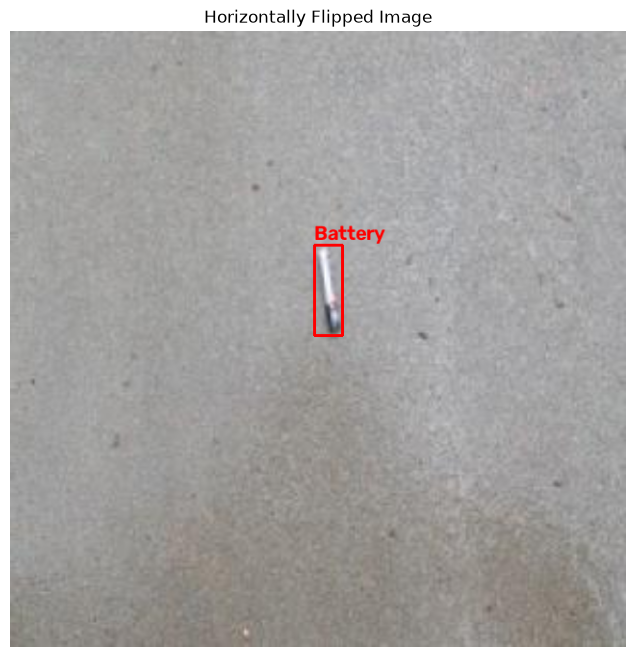

In [21]:
flipped_image_with_boxes = flipped_image.copy()

for obj in flipped_objects:

    xmin = int(obj["xmin"])
    ymin = int(obj["ymin"])
    xmax = int(obj["xmax"])
    ymax = int(obj["ymax"])

    class_name = obj["class_name"]

    cv2.rectangle(
        flipped_image_with_boxes,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

    cv2.putText(
        flipped_image_with_boxes,
        class_name,
        (xmin, max(ymin - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8, 8))
plt.imshow(flipped_image_with_boxes)
plt.title("Horizontally Flipped Image")
plt.axis("off")
plt.show()


## 15. Simple Brightness Augmentation

Brightness augmentation changes the appearance of the image.

The bounding-box coordinates do not change because the object location
inside the image stays the same.


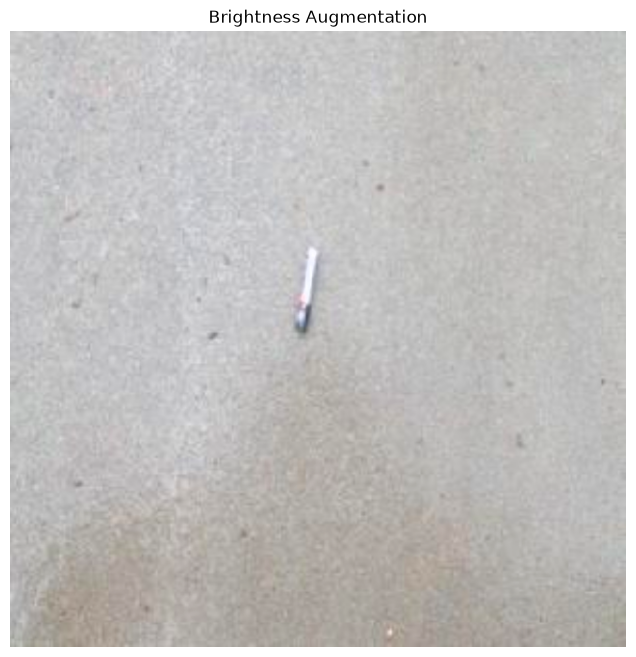

In [22]:
# Convert image to HSV
hsv_image = cv2.cvtColor(resized_image, cv2.COLOR_RGB2HSV)

# Increase brightness
hsv_image[:, :, 2] = np.clip(
    hsv_image[:, :, 2].astype(np.int16) + 30,
    0,
    255
).astype(np.uint8)

brighter_image = cv2.cvtColor(
    hsv_image,
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(8, 8))
plt.imshow(brighter_image)
plt.title("Brightness Augmentation")
plt.axis("off")
plt.show()


## 16. Compare Original and Augmented Image

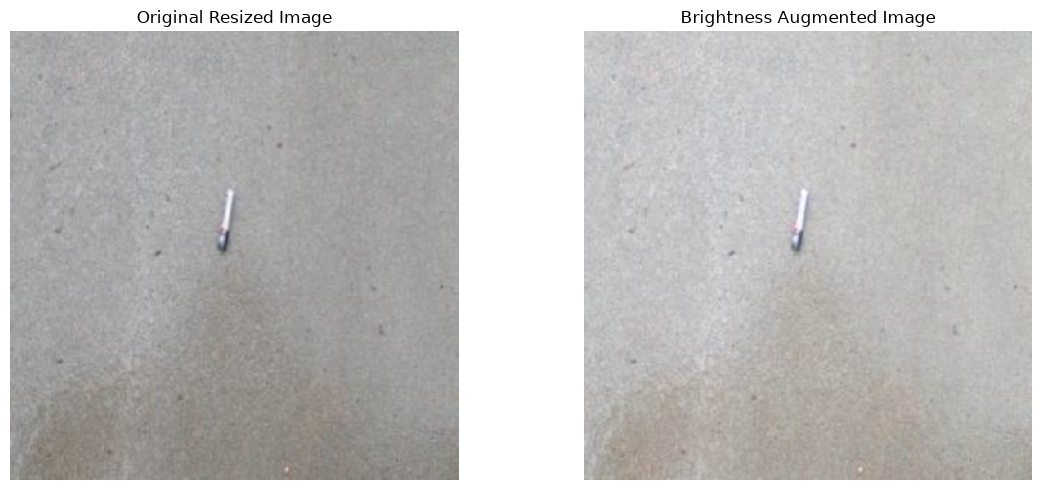

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(resized_image)
plt.title("Original Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(brighter_image)
plt.title("Brightness Augmented Image")
plt.axis("off")

plt.tight_layout()
plt.show()


## 17. Check Different Image Sizes

In [25]:
sample_images = df["image_id"].drop_duplicates().head(5)

for image_id in sample_images:

    # Get the original filename from the dataframe
    image_filename = df.loc[
        df["image_id"] == image_id,
        "filename"
    ].iloc[0]

    image_path = IMAGE_DIR / image_filename

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load: {image_path}")
        continue

    height, width = image.shape[:2]

    print(
        f"{image_filename} -> "
        f"width: {width}, height: {height}"
    )

000000.jpg -> width: 300, height: 300
000001.jpg -> width: 300, height: 300
000002.jpg -> width: 300, height: 300
000003.jpg -> width: 300, height: 300
000004.jpg -> width: 300, height: 300


## 18. Important Preprocessing Decisions

For the object-detection model, preprocessing must preserve the relationship
between the image and its bounding boxes.

Important rules:

1. If an image is resized, bounding boxes must also be resized.
2. If an image is horizontally flipped, bounding boxes must also be flipped.
3. Brightness changes do not require bounding-box changes.
4. Pixel normalization changes image values, not object coordinates.
5. We should not apply an augmentation that makes the annotation incorrect.

The final training pipeline will use the model framework's dataset
preprocessing and augmentation mechanisms where appropriate.


## 19. Summary

In this notebook we learned:

- How to load FOD-A images.
- How to read Pascal VOC XML annotations.
- How to extract FOD classes and bounding boxes.
- How to visualize bounding boxes.
- How image resizing affects bounding boxes.
- How to normalize image pixel values.
- How horizontal flipping affects bounding boxes.
- How brightness augmentation works.
- Why image augmentation must preserve annotation correctness.

The next notebook will introduce the CNN baseline.
